In [10]:
import pandas as pd

df = pd.read_csv("carclaims.csv")

print(df.shape)
print(df.info())
print(df.isnull().sum())

(15420, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  PolicyNumber          15

In [11]:
df['FraudFound'] = df['FraudFound'].map({'No': 0, 'Yes': 1})

In [12]:
X = df.drop('FraudFound', axis=1)
y = df['FraudFound']

In [13]:
df = df.drop(['PolicyNumber', 'RepNumber'], axis=1)

In [14]:
df = pd.get_dummies(df, drop_first=True)

In [15]:
import pandas as pd

df = pd.read_csv("carclaims.csv")
df = df.drop(['PolicyNumber', 'RepNumber'], axis=1)
df['FraudFound'] = df['FraudFound'].map({'No': 0, 'Yes': 1})
X = df.drop('FraudFound', axis=1)
y = df['FraudFound']
X = pd.get_dummies(X, drop_first=True)

print(X.shape)
print(y.shape)

(15420, 122)
(15420,)


In [16]:
from imblearn.over_sampling import SMOTE

# Remove rows where y is NaN
mask = y.notna()

X_clean = X[mask]
y_clean = y[mask]

# Apply SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_clean, y_clean)

print("Before SMOTE:")
print(y_clean.value_counts())

print("After SMOTE:")
print(y_res.value_counts())

Before SMOTE:
FraudFound
0    14497
1      923
Name: count, dtype: int64
After SMOTE:
FraudFound
0    14497
1    14497
Name: count, dtype: int64


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [19]:
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred))

Confusion Matrix:
 [[2879   20]
 [ 143 2757]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97      2899
           1       0.99      0.95      0.97      2900

    accuracy                           0.97      5799
   macro avg       0.97      0.97      0.97      5799
weighted avg       0.97      0.97      0.97      5799


ROC-AUC Score: 0.9718953622533335


Fault_Third Party               0.079100
PolicyType_Sedan - Liability    0.065216
BasePolicy_Liability            0.061953
VehicleCategory_Sport           0.042569
Age                             0.033557
Make_Pontiac                    0.020535
Year                            0.019960
WeekOfMonth                     0.019910
NumberOfSuppliments_3 to 5      0.019067
DayOfWeekClaimed_Thursday       0.019050
dtype: float64


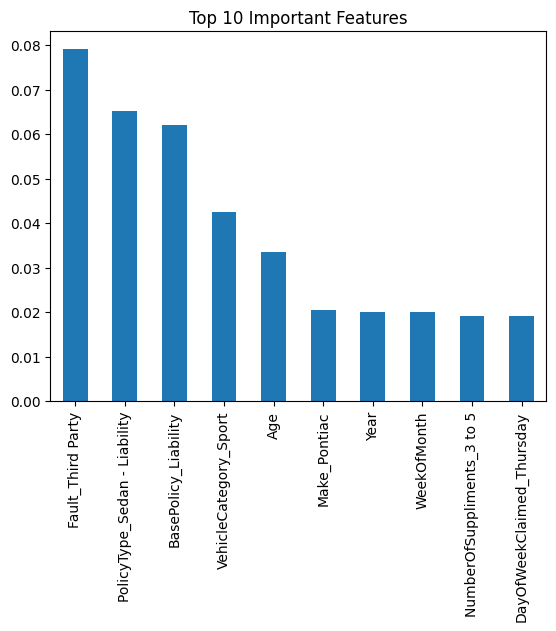

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

print(feat_imp.head(10))

feat_imp.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

In [22]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2899
           1       0.97      0.95      0.96      2900

    accuracy                           0.96      5799
   macro avg       0.96      0.96      0.96      5799
weighted avg       0.96      0.96      0.96      5799



In [23]:
from sklearn.model_selection import GridSearchCV

In [24]:
import joblib

joblib.dump(xgb, "fraud_model.pkl")

['fraud_model.pkl']

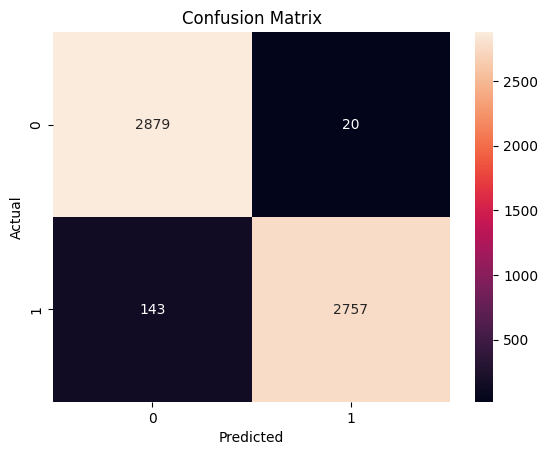

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

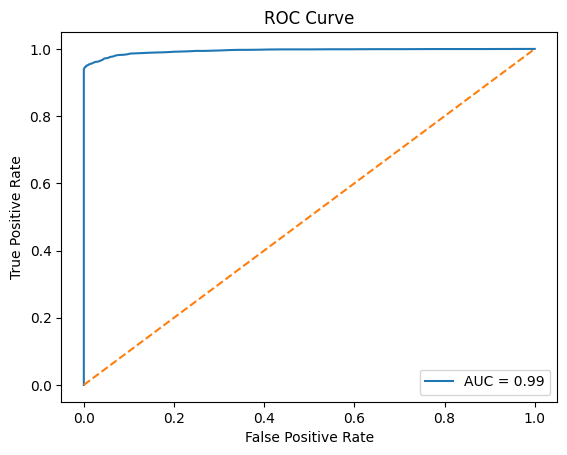

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probability scores
y_prob = model.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
auc_score = roc_auc_score(y_test, y_prob)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random model line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

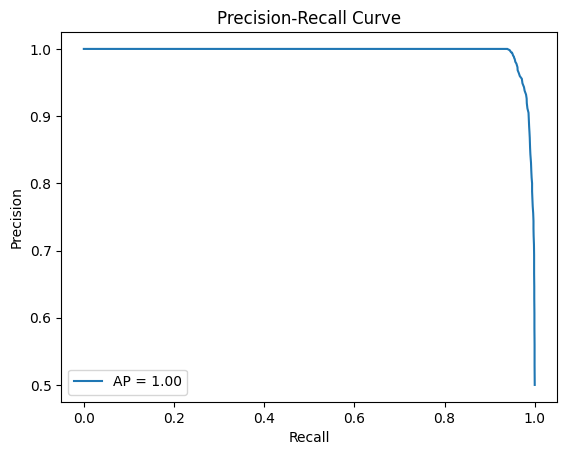

In [27]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Get probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Compute precision-recall
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Average Precision Score
ap_score = average_precision_score(y_test, y_prob)

# Plot
plt.figure()
plt.plot(recall, precision, label=f"AP = {ap_score:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

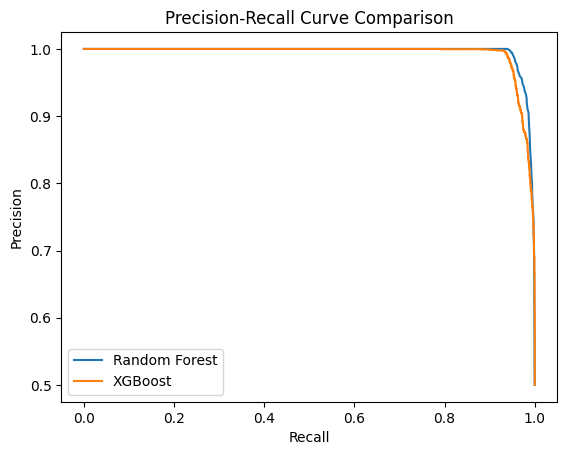

In [28]:
# Random Forest
y_prob_rf = model.predict_proba(X_test)[:, 1]
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)

# XGBoost
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)

plt.figure()
plt.plot(recall_rf, precision_rf, label="Random Forest")
plt.plot(recall_xgb, precision_xgb, label="XGBoost")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

In [29]:
import joblib

# Save model
joblib.dump(model, "fraud_model.pkl")

# Save column names
joblib.dump(X.columns, "columns.pkl")

['columns.pkl']

In [30]:
import pandas as pd
import joblib

# Load model and columns
model = joblib.load("fraud_model.pkl")
columns = joblib.load("columns.pkl")

In [31]:
sample = {
    'Age': 35,
    'Deductible': 400,
    'DriverRating': 3
}

In [32]:
input_df = pd.DataFrame([sample])

In [33]:
input_df = input_df.reindex(columns=columns, fill_value=0)

In [34]:
prediction = model.predict(input_df)[0]
probability = model.predict_proba(input_df)[0][1]

In [35]:
if prediction == 1:
    print("⚠️ Fraud Detected")
else:
    print("✅ Legitimate Claim")

print(f"Fraud Probability: {probability:.2f}")

⚠️ Fraud Detected
Fraud Probability: 1.00


In [36]:
import pandas as pd

df = pd.read_csv("carclaims.csv")

# Drop useless columns
df = df.drop(['PolicyNumber', 'RepNumber'], axis=1)

# Target
y = df['FraudFound'].map({'No': 0, 'Yes': 1})
X = df.drop('FraudFound', axis=1)

# Identify column types
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64']).columns

print("Categorical:", len(categorical_cols))
print("Numerical:", len(numerical_cols))

Categorical: 24
Numerical: 6


In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ]
)

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [39]:
pipeline.fit(X, y)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed',
       'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType',
       'VehicleCategory', 'VehiclePrice', 'Days:Policy-Accident',
       'Days:Policy-Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange-Claim', 'NumberOfCars',
       'BasePolicy'],
      dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'Deductible',
       'DriverRating', 'Year'],
      dtype='object'))])),
                ('model', RandomForestClassifier(random_state=42))])

In [40]:
import joblib

joblib.dump(pipeline, "fraud_pipeline.pkl")

['fraud_pipeline.pkl']

In [41]:
import joblib
import pandas as pd

# Load pipeline
model = joblib.load("fraud_pipeline.pkl")

# New sample (RAW format)
sample = {
    'Month': 'Jan',
    'WeekOfMonth': 2,
    'DayOfWeek': 'Monday',
    'Make': 'Honda',
    'AccidentArea': 'Urban',
    'DayOfWeekClaimed': 'Tuesday',
    'MonthClaimed': 'Jan',
    'WeekOfMonthClaimed': 2,
    'Sex': 'Male',
    'MaritalStatus': 'Single',
    'Age': 30,
    'Fault': 'Policy Holder',
    'PolicyType': 'Sedan - All Perils',
    'VehicleCategory': 'Sedan',
    'VehiclePrice': '20000 to 29000',
    'Deductible': 400,
    'DriverRating': 3,
    'Days:Policy-Accident': 'more than 30',
    'Days:Policy-Claim': 'more than 30',
    'PastNumberOfClaims': 'none',
    'AgeOfVehicle': '3 years',
    'AgeOfPolicyHolder': '26 to 30',
    'PoliceReportFiled': 'No',
    'WitnessPresent': 'No',
    'AgentType': 'External',
    'NumberOfSuppliments': 'none',
    'AddressChange-Claim': 'no change',
    'NumberOfCars': '1 vehicle',
    'Year': 1994,
    'BasePolicy': 'All Perils'
}

# Convert to DataFrame
input_df = pd.DataFrame([sample])

# Predict
prediction = model.predict(input_df)[0]
probability = model.predict_proba(input_df)[0][1]

# Output
if prediction == 1:
    print("⚠️ Fraud Detected")
else:
    print("✅ Legitimate Claim")

print(f"Fraud Probability: {probability:.2f}")

✅ Legitimate Claim
Fraud Probability: 0.26


In [42]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

pipeline = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ('smote', SMOTE()),
    ('model', RandomForestClassifier())
])

In [43]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Load data
df = pd.read_csv("carclaims.csv")
df = df.drop(['PolicyNumber', 'RepNumber'], axis=1)

y = df['FraudFound'].map({'No': 0, 'Yes': 1})
X = df.drop('FraudFound', axis=1)

categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64']).columns

# Preprocessing
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', 'passthrough', numerical_cols)
])

# Pipeline
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

# Hyperparameters
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [2, 5]
}

# Grid Search
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='recall',   # 🔥 important for fraud detection
    n_jobs=-1
)

grid.fit(X, y)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

best_model = grid.best_estimator_

Best Params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best Score: 0.015179717134114529


In [44]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        eval_metric='logloss'
    ))
])

xgb_pipeline.fit(X, y)

# Save it
import joblib
joblib.dump(xgb_pipeline, "xgb_pipeline.pkl")

['xgb_pipeline.pkl']

In [45]:
param_grid_xgb = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1]
}

grid_xgb = GridSearchCV(
    xgb_pipeline,
    param_grid_xgb,
    cv=3,
    scoring='recall',
    n_jobs=-1
)

grid_xgb.fit(X, y)

best_xgb = grid_xgb.best_estimator_

In [46]:
import numpy as np

# Get trained model
model = xgb_pipeline.named_steps['model']

# Get feature names AFTER preprocessing
ohe = xgb_pipeline.named_steps['preprocessing'].named_transformers_['cat']

cat_features = ohe.get_feature_names_out(categorical_cols)
all_features = np.concatenate([cat_features, numerical_cols])

# Feature importance
importances = model.feature_importances_

# Create dataframe
feat_imp = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp.head(10))

                              Feature  Importance
139              BasePolicy_Liability    0.145631
67                Fault_Policy Holder    0.110796
128  AddressChange-Claim_2 to 3 years    0.070401
70       PolicyType_Sedan - Collision    0.040754
55                   MonthClaimed_Jun    0.015037
10                          Month_Oct    0.013162
58                   MonthClaimed_Nov    0.012684
145                              Year    0.011953
52                   MonthClaimed_Feb    0.011653
11                          Month_Sep    0.011008


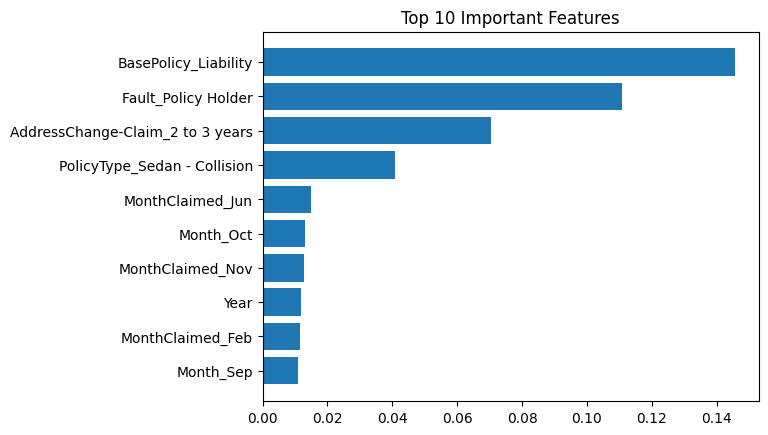

In [47]:
import matplotlib.pyplot as plt

top_features = feat_imp.head(10)

plt.figure()
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

In [48]:
import joblib

# Save best model (use best_xgb or best_model)
joblib.dump(xgb_pipeline, "fraud_pipeline.pkl")

['fraud_pipeline.pkl']